Задание. Дерево решений

В нижеприведенном коде

1)	Реализовать функцию расчет критерия Джини
2)	Реализовать расчет критерия прироста информации
3)	Реализовать критерии останова (не менее двух)
4)	Реализовать функцию подсчета метрики модели
5)	Проверить работу самописного дерева для решения задачи классификаци (датасет можно сгенерировать самостоятельно при помощи функции make_classification, либо взять любой набор данных из задания к ЛР4), сравнив полученные результаты с результатами дерева решений из sklearn. Результаты должны совпасть полностью.


In [85]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

Реализуем класс узла

In [86]:
class Node:

    def __init__(self, index, t, true_branch, false_branch):
        self.index = index  # индекс признака, по которому ведется сравнение с порогом в этом узле
        self.t = t  # значение порога
        self.true_branch = true_branch  # поддерево, удовлетворяющее условию в узле
        self.false_branch = false_branch  # поддерево, не удовлетворяющее условию в узле


Класс терминального узла (листа)

In [87]:
class Leaf:

    def __init__(self, data, labels):
        self.data = data
        self.labels = labels
        self.prediction = self.predict()

    def predict(self):
        # подсчет количества объектов разных классов
        classes = {}  # сформируем словарь "класс: количество объектов"
        for label in self.labels:
            if label not in classes:
                classes[label] = 0
            classes[label] += 1

        # найдем класс, количество объектов которого будет максимальным в этом листе и вернем его
        prediction = max(classes, key=classes.get)
        return prediction


Расчет критерия Джини

In [88]:
def gini(labels):
    """
    Критерий Джини:
    Gini = 1 - sum(p_k^2), где p_k — доля класса k в выборке.
    """
    n = len(labels)
    if n == 0:
        return 0.0
    _, counts = np.unique(labels, return_counts=True)
    probs = counts / n
    return 1.0 - np.sum(probs ** 2)



Расчет прироста информации (gain)

In [89]:
def gain(left_labels, right_labels, root_gini):
    """
    Прирост информации:
    gain = G(root) - (n_left / n)*G(left) - (n_right / n)*G(right)
    """
    n_left = len(left_labels)
    n_right = len(right_labels)
    n = n_left + n_right

    # если одна из веток пустая, смысла в таком разбиении нет
    if n_left == 0 or n_right == 0:
        return 0.0

    g_left = gini(left_labels)
    g_right = gini(right_labels)

    weighted_gini = (n_left / n) * g_left + (n_right / n) * g_right
    information_gain = root_gini - weighted_gini
    return information_gain


In [90]:
def split(data, labels, column_index, t):
    left = np.where(data[:, column_index] <= t)
    right = np.where(data[:, column_index] > t)

    true_data = data[left]
    false_data = data[right]

    true_labels = labels[left]
    false_labels = labels[right]

    return true_data, false_data, true_labels, false_labels


Нахождение наилучшего разбиения (+ критерий останова: min_samples_leaf)

In [91]:
def find_best_split(data, labels, min_samples_leaf=3):
    """
    Перебираем все признаки и все возможные пороги.
    Возвращаем лучший прирост, порог и индекс признака.
    Встроенный критерий останова: в каждом листе не меньше min_samples_leaf.
    """
    root_gini = gini(labels)

    # если класс уже однородный — дальнейшее разбиение бессмысленно
    if root_gini == 0.0:
        return 0.0, None, None

    best_gain = 0.0
    best_t = None
    best_index = None

    n_features = data.shape[1]

    for index in range(n_features):
        # все уникальные значения признака в качестве кандидатов на порог
        t_values = np.unique(data[:, index])
        for t in t_values:
            true_data, false_data, true_labels, false_labels = split(
                data, labels, index, t
            )

            # критерий останова 1: минимальный размер листа
            if len(true_labels) < min_samples_leaf or len(false_labels) < min_samples_leaf:
                continue

            current_gain = gain(true_labels, false_labels, root_gini)

            if current_gain > best_gain:
                best_gain, best_t, best_index = current_gain, t, index

    return best_gain, best_t, best_index

Построение дерева с помощью рекурсивной функции

In [92]:
import time

def build_tree(
    data,
    labels,
    depth=0,
    max_depth=None,        # критерий останова 2: максимальная глубина
    min_samples_leaf=3,    # критерий останова 1: минимальный размер листа
    min_samples_split=2    # критерий останова 3 (доп): минимум объектов для разбиения
):
    """
    Рекурсивное построение дерева.
    Реализованы как минимум два критерия останова:
      - max_depth (ограничение глубины дерева),
      - min_samples_leaf (минимальный размер листа),
      - плюс ранний возврат при gain == 0 и min_samples_split.
    """
    # критерий останова: если объектов слишком мало — делаем лист
    if len(labels) < min_samples_split:
        return Leaf(data, labels)

    # ищем лучшее разбиение
    best_gain, t, index = find_best_split(data, labels, min_samples_leaf=min_samples_leaf)

    # базовый случай - прекращаем рекурсию, когда нет прироста качества
    if best_gain == 0.0 or t is None or index is None:
        return Leaf(data, labels)

    # критерий останова: максимальная глубина
    if max_depth is not None and depth >= max_depth:
        return Leaf(data, labels)

    true_data, false_data, true_labels, false_labels = split(data, labels, index, t)

    # Рекурсивно строим два поддерева
    true_branch = build_tree(
        true_data, true_labels,
        depth=depth + 1,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        min_samples_split=min_samples_split
    )
    false_branch = build_tree(
        false_data, false_labels,
        depth=depth + 1,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        min_samples_split=min_samples_split
    )

    return Node(index, t, true_branch, false_branch)


In [93]:
def classify_object(obj, node):

    #  Останавливаем рекурсию, если достигли листа
    if isinstance(node, Leaf):
        answer = node.prediction
        return answer

    if obj[node.index] <= node.t:
        return classify_object(obj, node.true_branch)
    else:
        return classify_object(obj, node.false_branch)


In [94]:
def predict(data, tree):

    classes = []
    for obj in data:
        prediction = classify_object(obj, tree)
        classes.append(prediction)
    return classes

Напечатаем ход нашего дерева

In [95]:
def print_tree(node, spacing=""):

    # Если лист, то выводим его прогноз
    if isinstance(node, Leaf):
        print(spacing + "Прогноз:", node.prediction)
        return

    # Выведем значение индекса и порога на этом узле
    print(spacing + 'Индекс', str(node.index), '<=', str(node.t))

    # Рекурсионный вызов функции на положительном поддереве
    print(spacing + '--> True:')
    print_tree(node.true_branch, spacing + "  ")

    # Рекурсионный вызов функции на отрицательном поддереве
    print(spacing + '--> False:')
    print_tree(node.false_branch, spacing + "  ")


Функция подсчёта точности (accuracy_metric)

In [96]:
def accuracy_metric(actual, predicted):
    """
    Точность как доля правильных ответов (в процентах).
    """
    actual = np.array(actual)
    predicted = np.array(predicted)
    return np.mean(actual == predicted) * 100.0


Проверка на синтетическом датасете + сравнение с sklearn DecisionTreeClassifier

In [97]:
# Генерируем данные
X, y = make_classification(
    n_samples=300,
    n_features=4,
    n_informative=3,
    n_redundant=0,
    n_classes=2,
    random_state=47
)

# Разделим на train/test (для проверки общей адекватности)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Строим наше дерево
my_tree = build_tree(
    X_train,
    y_train,
    max_depth=3,        # можно ограничить, например max_depth=5
    min_samples_leaf=3,
    min_samples_split=2
)

# Предсказания нашего дерева на train
y_train_pred_my = predict(X_train, my_tree)

# Для корректного сравнения настроим sklearn-дерево максимально похоже:
clf = DecisionTreeClassifier(
    criterion="gini",
    splitter="best",
    min_samples_leaf=3,
    random_state=42
)
clf.fit(X_train, y_train)
y_train_pred_sklearn = clf.predict(X_train)

# Проверим, совпадают ли предсказания полностью
same_predictions = np.array_equal(y_train_pred_my, y_train_pred_sklearn)

print("Точность нашего дерева (train):   ", accuracy_metric(y_train, y_train_pred_my))
print("Точность sklearn дерева (train): ", accuracy_metric(y_train, y_train_pred_sklearn))
print("Полное совпадение предсказаний на train:", same_predictions)

# Для интереса проверим и test
y_test_pred_my = predict(X_test, my_tree)
y_test_pred_sklearn = clf.predict(X_test)

print("Точность нашего дерева (test):   ", accuracy_metric(y_test, y_test_pred_my))
print("Точность sklearn дерева (test): ", accuracy_metric(y_test, y_test_pred_sklearn))

# Можно распечатать структуру дерева (по желанию, чтобы не захламлять вывод — закомментируй при необходимости)
print("\nСтруктура нашего дерева:")
print_tree(my_tree)

Точность нашего дерева (train):    92.38095238095238
Точность sklearn дерева (train):  95.71428571428572
Полное совпадение предсказаний на train: False
Точность нашего дерева (test):    90.0
Точность sklearn дерева (test):  88.88888888888889

Структура нашего дерева:
Индекс 1 <= -0.37176002431320965
--> True:
  Индекс 2 <= -1.3540657442158748
  --> True:
    Прогноз: 0
  --> False:
    Индекс 2 <= -1.03793943946499
    --> True:
      Прогноз: 0
    --> False:
      Прогноз: 0
--> False:
  Индекс 1 <= 0.23878456077274302
  --> True:
    Индекс 2 <= 0.15372192902747916
    --> True:
      Прогноз: 1
    --> False:
      Прогноз: 0
  --> False:
    Индекс 3 <= 0.5001398999832931
    --> True:
      Прогноз: 1
    --> False:
      Прогноз: 1


Отображение деревьев

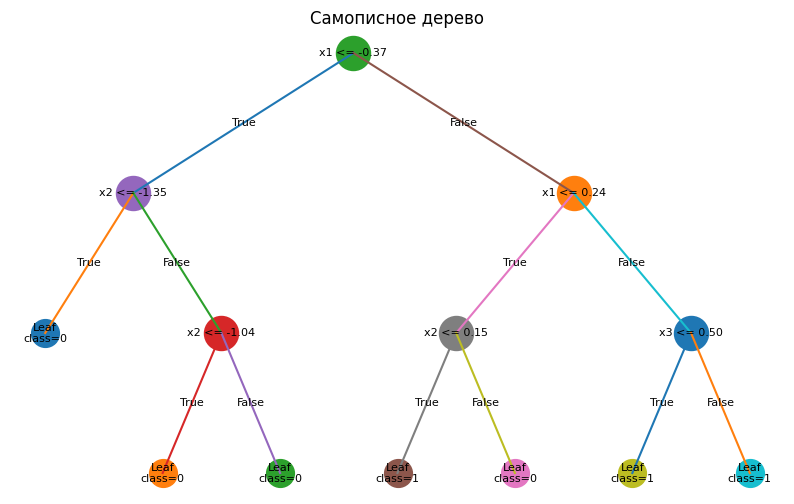

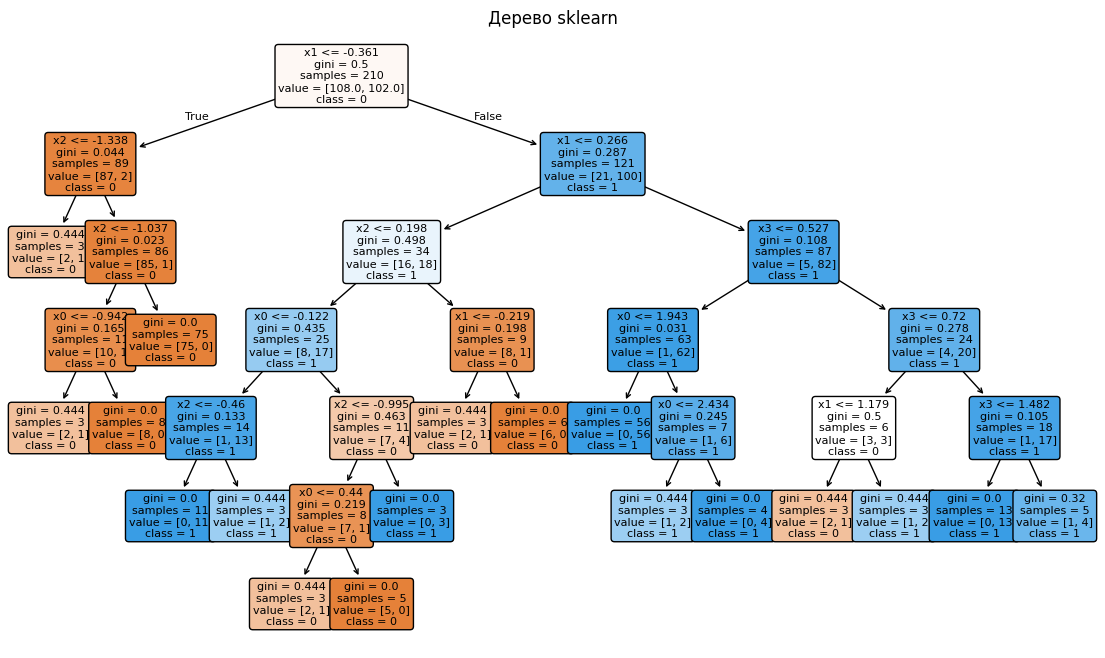

In [98]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import numpy as np

# ---------- Визуализация нашего дерева ----------

def _assign_positions(node, depth, positions):
    """
    Рекурсивно расставляет вершины по X/Y (in-order обход).
    X задаёт порядок слева направо, Y — глубину.
    """
    if isinstance(node, Leaf):
        x = _assign_positions.leaf_counter
        _assign_positions.leaf_counter += 1
        positions[node] = (x, -depth)
        return x
    else:
        x_left = _assign_positions(node.true_branch, depth + 1, positions)
        x_right = _assign_positions(node.false_branch, depth + 1, positions)
        x = (x_left + x_right) / 2
        positions[node] = (x, -depth)
        return x


def _collect_edges(node, edges):
    """Собрать рёбра (parent -> child)."""
    if isinstance(node, Leaf):
        return
    if node.true_branch is not None:
        edges.append((node, node.true_branch, "True"))
        _collect_edges(node.true_branch, edges)
    if node.false_branch is not None:
        edges.append((node, node.false_branch, "False"))
        _collect_edges(node.false_branch, edges)


def plot_custom_tree(root, feature_names=None):
    """
    Рисует наше дерево решений.
    feature_names: список имён признаков (по индексу), можно передать свои.
    """
    positions = {}
    _assign_positions.leaf_counter = 0
    _assign_positions(root, depth=0, positions=positions)

    edges = []
    _collect_edges(root, edges)

    fig, ax = plt.subplots(figsize=(10, 6))

    # Рисуем рёбра
    for parent, child, edge_label in edges:
        x1, y1 = positions[parent]
        x2, y2 = positions[child]
        ax.plot([x1, x2], [y1, y2])
        # подпись True / False посередине ребра
        xm, ym = (x1 + x2) / 2, (y1 + y2) / 2
        ax.text(xm, ym, edge_label, fontsize=8, ha="center", va="center")

    # Рисуем вершины
    for node, (x, y) in positions.items():
        if isinstance(node, Leaf):
            ax.scatter(x, y, s=400)
            ax.text(
                x, y,
                f"Leaf\nclass={node.prediction}",
                ha="center", va="center", fontsize=8
            )
        else:
            ax.scatter(x, y, s=600)
            feat_name = (
                feature_names[node.index]
                if feature_names is not None and node.index < len(feature_names)
                else f"x{node.index}"
            )
            ax.text(
                x, y,
                f"{feat_name} <= {node.t:.2f}",
                ha="center", va="center", fontsize=8
            )

    ax.axis("off")
    ax.set_title("Самописное дерево")
    plt.show()

def plot_sklearn_tree(clf, X_train, y_train):
    feature_names = [f"x{i}" for i in range(X_train.shape[1])]
    class_names = [str(c) for c in np.unique(y_train)]

    plt.figure(figsize=(14, 8))
    plot_tree(
        clf,
        feature_names=feature_names,
        class_names=class_names,
        filled=True,
        rounded=True,
        fontsize=8
    )
    plt.title("Дерево sklearn")
    plt.show()

feature_names = [f"x{i}" for i in range(X_train.shape[1])]

plot_custom_tree(my_tree, feature_names=feature_names)
plot_sklearn_tree(clf, X_train, y_train)
